In [ ]:
# ANALISIS DE MÉTRICAS DE EXPANSION CLONAL Y DIVERSIDAD 
# Este script aplica un conjunto de enfoques complementarios para caracterizar
# la diversidad alfa en tu repertorio: primero calcula los números de Hill 
# mediante alphaDiversity de alakazam ; luego incorpora métricas adicionales 
# con vegan como índices de diversidad y equidad para describir la distribución
# de abundancias; y finalmente utiliza ineq para estimar desigualdad clonal a través
# del índice de Gini y otras medidas de concentración. Al combinar estas diez métricas, 
# obtienes una visión integrada de la cantidad, equilibrio y desigualdad en la arquitectura 
# clonal de tu repertorio.



In [1]:

# Luego de clustering archivo _clone-pass.tsv se realiza analisis de métricas
# Paquetes y librerías
library(readr)
library(dplyr)
library(ggplot2)
library(viridisLite)
library(here)  # para rutas relativas
# install.packages("alakazam")
library(alakazam)
library(ineq)
library(vegan)
library(tidyr)

# actualizar renv despues de la instalación de cada paquete
# renv::snapshot()


# Configuración de archivo

carpeta_archivo <- "../data/output"  
nombre_archivo <- "repertorio_A_insilico_30_seqs_clone-pass.tsv"

# Construir ruta relativa
archivo_clones <- here(carpeta_archivo, nombre_archivo)

# Cargar archivo
clones <- read_tsv(archivo_clones)
head(clones, 5)


Attaching package: 'dplyr'


The following objects are masked from 'package:stats':

    filter, lag


The following objects are masked from 'package:base':

    intersect, setdiff, setequal, union


here() starts at /Users/catg/Desktop/SOFIAC/Gitsofia/tesisbioinf-sofia/notebooks

Warning message:
"replacing previous import 'S4Arrays::makeNindexFromArrayViewport' by 'DelayedArray::makeNindexFromArrayViewport' when loading 'SummarizedExperiment'"


To cite the alakazam package in publications, please use:

  Gupta N, Vander Heiden J, Uduman M, Gadala-Maria D, Yaari G,
  Kleinstein S (2015). "Change-O: a toolkit for analyzing large-scale B
  cell immunoglobulin repertoire sequencing data." _Bioinformatics_,
  1-3. doi:10.1093/bioinformatics/btv359
  <https://doi.org/10.1093/bioinformatics/btv359>.

To cite the Ig-specific lineage reconstruction and diversity methods,
please use:

  Stern J, Yaari G, Vander Heiden J, Church G, Donahue W, Hintzen R,
  Huttner A, Laman J, Nagra R, Nylander

sequence_id,sequence,rev_comp,productive,v_call,d_call,j_call,sequence_alignment,germline_alignment,junction,...,j_identity,j_support,fwr1,fwr2,fwr3,fwr4,cdr1,cdr2,cdr3,clone_id
<chr>,<chr>,<lgl>,<lgl>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,...,<dbl>,<dbl>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<dbl>
seq5,CAGGTGCAGCTGGTGCAGTCTGGGGCTGAGGTGAAGAAGCCTGGGGCCTCAGTGAAGGTTTCCTGCAAGGCATCTGGATACACCTTCACCAGCTACTATATGCACTGGGTGCGACAGGCCCCTGGACAAGGGCTTGAGTGGATGGGAATAATCAACCCTAGTGGTGGTAGCACAAGCTACGCACAGAAGTTCCAGGGCAGAGTCACCATGACCAGGGACACGTCCACGAGCACAGTCTACATGGAGCTGAGCAGCCTGAGATCTGAGGACACGGCCGTGTATTACTGTGCGAGAGAGTATAGCAGCAGCTTGGACTACTTTGACTACTGGGGCCAAGGAACCCTGGTCACCGTCTCCTCA,FALSE,TRUE,IGHV1-46*01,IGHD6-13*01,IGHJ4*01,CAGGTGCAGCTGGTGCAGTCTGGGGCT...GAGGTGAAGAAGCCTGGGGCCTCAGTGAAGGTTTCCTGCAAGGCATCTGGATACACCTTC............ACCAGCTACTATATGCACTGGGTGCGACAGGCCCCTGGACAAGGGCTTGAGTGGATGGGAATAATCAACCCTAGT......GGTGGTAGCACAAGCTACGCACAGAAGTTCCAG...GGCAGAGTCACCATGACCAGGGACACGTCCACGAGCACAGTCTACATGGAGCTGAGCAGCCTGAGATCTGAGGACACGGCCGTGTATTACTGTGCGAGAGAGTATAGCAGCAGCTTGGACTACTTTGACTACTGGGGCCAAGGAACCCTGGTCACCGTCTCCTCA,CAGGTGCAGCTGGTGCAGTCTGGGGCT...GAGGTGAAGAAGCCTGGGGCCTCAGTGAAGGTTTCCTGCAAGGCATCTGGATACACCTTC............ACCAGCTACTATATGCACTGGGTGCGACAGGCCCCTGGACAAGGGCTTGAGTGGATGGGAATAATCAACCCTAGT......GGTGGTAGCACAAGCTACGCACAGAAGTTCCAG...GGCAGAGTCACCATGACCAGGGACACGTCCACGAGCACAGTCTACATGGAGCTGAGCAGCCTGAGATCTGAGGACACGGCCGTGTATTACTGTGCGAGAGAGTATAGCAGCAGCTNNNACTACTTTGACTACTGGGGCCAAGGAACCCTGGTCACCGTCTCCTCA,TGTGCGAGAGAGTATAGCAGCAGCTTGGACTACTTTGACTACTGG,...,1,1.61e-22,CAGGTGCAGCTGGTGCAGTCTGGGGCT...GAGGTGAAGAAGCCTGGGGCCTCAGTGAAGGTTTCCTGCAAGGCATCT,ATGCACTGGGTGCGACAGGCCCCTGGACAAGGGCTTGAGTGGATGGGAATA,AGCTACGCACAGAAGTTCCAG...GGCAGAGTCACCATGACCAGGGACACGTCCACGAGCACAGTCTACATGGAGCTGAGCAGCCTGAGATCTGAGGACACGGCCGTGTATTACTGT,TGGGGCCAAGGAACCCTGGTCACCGTCTCCTCA,GGATACACCTTC............ACCAGCTACTAT,ATCAACCCTAGT......GGTGGTAGCACA,GCGAGAGAGTATAGCAGCAGCTTGGACTACTTTGACTAC,1
seq7,GAGGTGCAGCTGGTGGAGTCTGGGGGAGGCTTGGTAAAGCCTGGGGGGTCCCTTAGACTCTCCTGTGCAGCCTCTGGATTCACTTTCAGTAACGCCTGGATGAGCTGGGTCCGCCAGGCTCCAGGGAAGGGGCTGGAGTGGGTTGGCCGTATTAAAAGCAAAACTGATGGTGGGACAACAGACTACGCTGCACCCGTGAAAGGCAGATTCACCATCTCAAGAGATGATTCAAAAAACACGCTGTATCTGCAAATGAACAGCCTGAAAACCGAGGACACAGCCGTGTATTACTGTACCACAGATTGCTATGGTTCGGGGAGTTCCTTTGACTACTGGGGCCAAGGAACCCTGGTCACCGTCTCCTCA,FALSE,TRUE,IGHV3-15*01,IGHD3-10*01,IGHJ4*01,GAGGTGCAGCTGGTGGAGTCTGGGGGA...GGCTTGGTAAAGCCTGGGGGGTCCCTTAGACTCTCCTGTGCAGCCTCTGGATTCACTTTC............AGTAACGCCTGGATGAGCTGGGTCCGCCAGGCTCCAGGGAAGGGGCTGGAGTGGGTTGGCCGTATTAAAAGCAAAACTGATGGTGGGACAACAGACTACGCTGCACCCGTGAAA...GGCAGATTCACCATCTCAAGAGATGATTCAAAAAACACGCTGTATCTGCAAATGAACAGCCTGAAAACCGAGGACACAGCCGTGTATTACTGTACCACAGATTGCTATGGTTCGGGGAGTTCCTTTGACTACTGGGGCCAAGGAACCCTGGTCACCGTCTCCTCA,GAGGTGCAGCTGGTGGAGTCTGGGGGA...GGCTTGGTAAAGCCTGGGGGGTCCCTTAGACTCTCCTGTGCAGCCTCTGGATTCACTTTC............AGTAACGCCTGGATGAGCTGGGTCCGCCAGGCTCCAGGGAAGGGGCTGGAGTGGGTTGGCCGTATTAAAAGCAAAACTGATGGTGGGACAACAGACTACGCTGCACCCGTGAAA...GGCAGATTCACCATCTCAAGAGATGATTCAAAAAACACGCTGTATCTGCAAATGAACAGCCTGAAAACCGAGGACACAGCCGTGTATTACTGTACCACAGANNNCTATGGTTCGGGGAGTTNCTTTGACTACTGGGGCCAAGGAACCCTGGTCACCGTCTCCTCA,TGTACCACAGATTGCTATGGTTCGGGGAGTTCCTTTGACTACTGG,...,1,3.38e-20,GAGGTGCAGCTGGTGGAGTCTGGGGGA...GGCTTGGTAAAGCCTGGGGGGTCCCTTAGACTCTCCTGTGCAGCCTCT,ATGAGCTGGGTCCGCCAGGCTCCAGGGAAGGGGCTGGAGTGGGTTGGCCGT,GACTACGCTGCACCCGTGAAA...GGCAGATTCACCATCTCAAGAGATGATTCAAAAAACACGCTGTATCTGCAAATGAACAGCCTGAAAACCGAGGACACAGCCGTGTATTACTGT,TGGGGCCAAGGAACCCTGGTCACCGTCTCCTCA,GGATTCACTTTC............AGTAACGCCTGG,ATTAAAAGCAAAACTGATGGTGGGACAACA,ACCACAGATTGCTATGGTTCGGGGAGTTCCTTTGACTAC,2
seq3,GAGGTGCAGCTGGTGGAGTCTGGGGGAGGCTTGGTAAAGCCTGGGGGGTCCCTTAGACTCTCCTGTGCAGCCTCTGGATTCACTTTCAGTAACGCCTGGATGAGCTGGGTCCGCCAGGCTCCAGGGAAGGGGCTGGAGTGGGTTGGCCGTATTAAAAGCAAAACTGATGGTGGGACAACAGACTACGCTGCACCCGTGAAAGGCAGATTCACCATCTCAAGAGATGATTCAAAAAACACGCTGTATCTGCAAATGAACAGCCTGAAAACCGAGGACACAGCCGTGTATTACTGTTCCCCGGGTATAGCAGTGGCTGGGGCGGGCTTTGACTACTGGGGCCAAGGAACCCTGGTCACCGTCTCCTCA,FALSE,TRUE,IGHV3-15*01,IGHD6-19*01,IGHJ4*01,GAGGTGCA

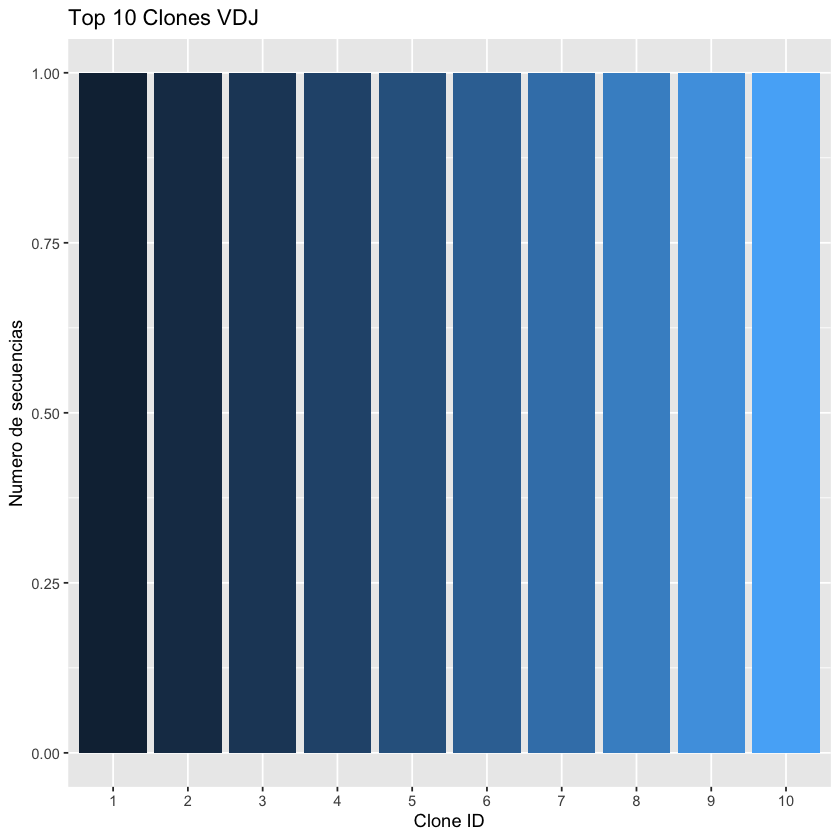

In [2]:
# Tamaño de cada clon

clon_size <- clones %>%
  group_by(clone_id) %>%
  summarise(n_seq = n(), .groups = "drop") %>%
  arrange(desc(n_seq)) %>%
  mutate(freq = n_seq / sum(n_seq))

# Top 10 clones

top10 <- arrange(clon_size, desc(freq)) %>%
  slice_head(n = 10)

ggplot(top10, aes(x = reorder(clone_id, -n_seq), y = n_seq, fill = clone_id)) +
  geom_col() +
  labs(title = "Top 10 Clones VDJ", x = "Clone ID", y = "Numero de secuencias") +
  theme(legend.position = "none")

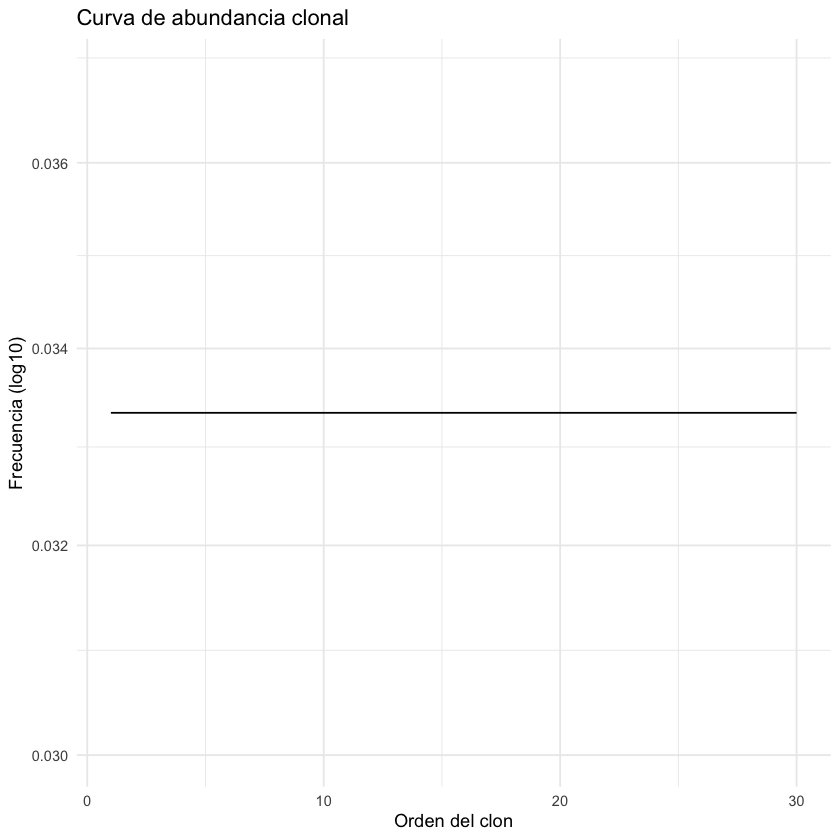

In [3]:
# Curva de abundancia clonal

clon_size %>%
  mutate(rank = row_number()) %>%
  ggplot(aes(x = rank, y = freq)) +
  geom_line() +
  scale_y_log10() +
  labs(title = "Curva de abundancia clonal", x = "Orden del clon", y = "Frecuencia (log10)") +
  theme_minimal()

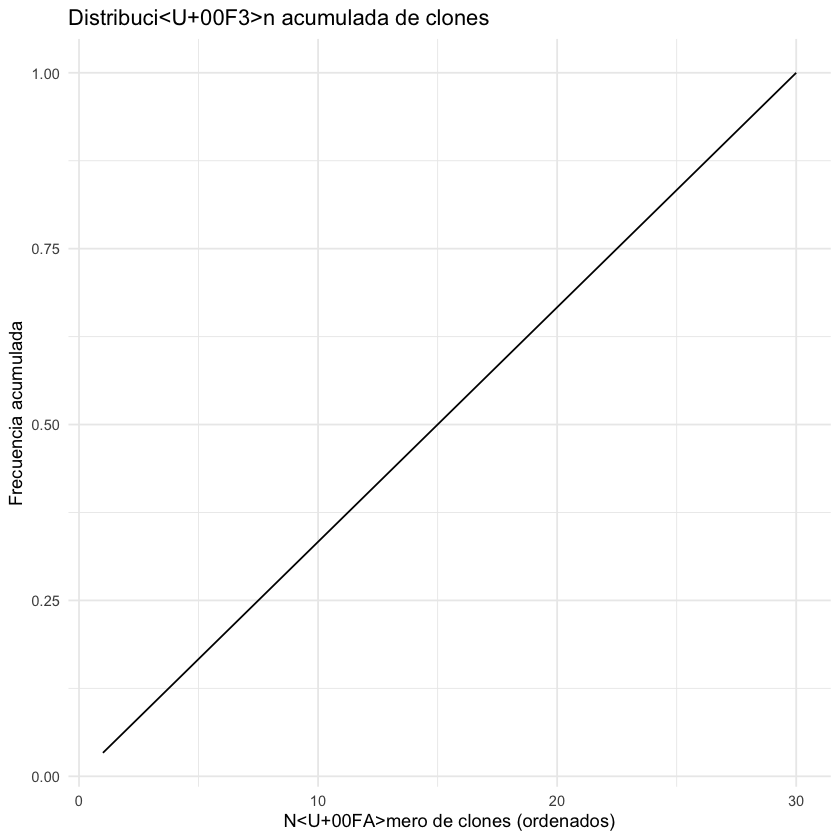

In [4]:
# Distribución acumulada

clon_size %>%
  mutate(cum_freq = cumsum(freq), rank = row_number()) %>%
  ggplot(aes(x = rank, y = cum_freq)) +
  geom_line() +
  labs(title = "Distribución acumulada de clones", x = "Número de clones (ordenados)", y = "Frecuencia acumulada") +
  theme_minimal()

In [5]:

# MÉTRICAS DE DIVERSIDAD
# Cargar tu archivo .tsv
archivo_clones <- "../data/output/repertorio_A_insilico_30_seqs_clone-pass.tsv"
clones <- read_tsv(archivo_clones)
# Agregar identificador de muestra (porque es simulado)
clones <- clones %>%
  mutate(sample_id = "repertorio_simulado")


# Contar secuencias por clon y muestra
clone_counts <- clones %>%
  group_by(sample_id, clone_id) %>%
  summarise(count = n(), .groups = "drop")

Rows: 30 Columns: 50
-- Column specification --------------------------------------------------------
Delimiter: "\t"
chr (20): sequence_id, sequence, v_call, d_call, j_call, sequence_alignment,...
dbl (25): junction_length, np1_length, np2_length, v_sequence_start, v_seque...
lgl  (5): rev_comp, productive, stop_codon, vj_in_frame, c_call

i Use `spec()` to retrieve the full column specification for this data.
i Specify the column types or set `show_col_types = FALSE` to quiet this message.


In [6]:
# METRICA HILL NUMBERS (SHANNON, SIMPSON, S, D3 Y D4) alakazam
# 1 shannon el valor es logaritmo de ese 1 ej: 28.6 log natural es 3.35

hill <- alphaDiversity(
  data = clone_counts,
  clone = "clone_id",
  min_q = 0,
  max_q = 4,
  step_q = 1,
  nboot = 100,
  ci =0.95,
)
print(hill@diversity)

# A tibble: 5 x 9
# Groups:   group [1]
  group     q     d  d_sd d_lower d_upper     e e_lower e_upper
  <chr> <dbl> <dbl> <dbl>   <dbl>   <dbl> <dbl>   <dbl>   <dbl>
1 All       0  29.2 0.873    27.4    30.9 1       0.941    1.06
2 All       1  28.9 1.19     26.5    31.2 0.990   0.910    1.07
3 All       2  28.4 1.65     25.2    31.7 0.975   0.864    1.09
4 All       3  27.8 2.25     23.4    32.2 0.955   0.803    1.11
5 All       4  27.1 2.90     21.4    32.8 0.930   0.735    1.13


In [11]:
readr::write_tsv(hill@diversity, "diversidad_hill.tsv")

In [7]:
# MÉTRICA CHAO1 y ACE PAQUETE VEGAN
metricas_chao1ace <- clone_counts %>%
  group_by(sample_id) %>% 
  summarise(
    chao1 = estimateR(count)["S.chao1"],
    ace   = estimateR(count)["S.ACE"]
  )

print(metricas_chao1ace)


# A tibble: 1 x 3
  sample_id           chao1   ace
  <chr>               <dbl> <dbl>
1 repertorio_simulado   465   NaN


In [16]:
estimateR(clone_counts$count)

S.obs  S.chao1 se.chao1    S.ACE   se.ACE 
 30.0000 465.0000 161.5767      NaN      NaN

In [13]:
readr::write_tsv(metricas_chao1ace, "metricas_chao1_ace.tsv")

In [8]:
# MÉTRICA GINI PAQUETE INEQ
calc_gini <- function(df) {
  ineq::ineq(df$count, type = "Gini")
}
gini_result <- clone_counts %>%
  group_by(sample_id) %>%
  summarise(
    gini = calc_gini(cur_data())
  )

print(gini_result)


Warning message:
"There was 1 warning in `summarise()`.
i In argument: `gini = calc_gini(cur_data())`.
i In group 1: `sample_id = "repertorio_simulado"`.
Caused by warning:
! `cur_data()` was deprecated in dplyr 1.1.0.
i Please use `pick()` instead."


# A tibble: 1 x 2
  sample_id            gini
  <chr>               <dbl>
1 repertorio_simulado     0


In [15]:
readr::write_tsv(gini_result, "gini_result.tsv")

In [9]:
# MÉTRICA PIELOU PAQUETE VEGAN

calc_pielou <- function(df) {
  abund <- df$count
  H <- diversity(abund, index = "shannon")  # Shannon
  S <- specnumber(abund)                    # número de clones
  J <- H / log(S)                           # Pielou
  return(J)
}

pielou_result <- clone_counts %>%
  group_by(sample_id) %>%
  summarise(
    pielou = calc_pielou(cur_data())
  )

print(pielou_result)



# A tibble: 1 x 2
  sample_id           pielou
  <chr>                <dbl>
1 repertorio_simulado      1


In [ ]:
readr::write_tsv(pielou_result, "pielou_result.tsv")

In [10]:
# MÉTRICA BASHARIN FUNCIONES R+ VEGAN

calc_basharin <- function(df) {
  abund <- df$count
  N <- sum(abund)
  S <- specnumber(abund)
  
  # Casos triviales
  if (N == 0 || S <= 1) return(0)
  
  H <- diversity(abund, index = "shannon")
  print(H)
  basharin <- H + (S - 1) / (2 * N)
  return(basharin)
}

# Aplicar por muestra
basharin_result <- clone_counts %>%
  group_by(sample_id) %>%
  summarise(basharin = calc_basharin(cur_data()), .groups = "drop")

print(basharin_result)




[1] 3.401197
# A tibble: 1 x 2
  sample_id           basharin
  <chr>                  <dbl>
1 repertorio_simulado     3.88


In [ ]:
readr::write_tsv(basharin_result, "basharin_result.tsv")

In [12]:

#  METRICA D50 FUNCIONES R Cuántos clones (ordenados de mayor a menor abundancia)
#  necesito sumar para que juntos acumulen el 50% de todas las secuencias de mi repertorio
d50_fun <- function(counts) {
  counts <- sort(counts, decreasing = TRUE)
  total <- sum(counts)
  cum <- cumsum(counts)
  which(cum >= 0.5 * total)[1]
}

# Calcular D50
d50_val <- d50_fun(clone_counts$count)
print(d50_val)


[1] 15


In [ ]:

readr::write_tsv(d50_result, "d50_result.tsv")